# Assignment 4

Linear Regression is useful, but it is not always applicable on a day to day basis. 
However, its formula, while straightforward, can be extended upon to give logistic regression - which is a lot more helpful for predicting on categorical data. 
We will now train a logistic regression model to predict if a loan should be approved based on certain features present in the dataset. 

In so doing, we’ll walk through 
- real-world data filtering
- feature engineering
- model training and 
- interpreting performance

In [2]:
# Ensure that the libraries below have been installed via pip/ pip3 (windows/mac)

import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Run this cell before executing all cells below

### Question 1
The dataset contains both numeric and categorical data within. It is helpful to transform it all in-place to numeric values to train a ML model. Recall that for nominal data (categorical data without implicit ranks) it is better to use One Hot Encoding. **However**, for simplicity's sake + the efficiency brought about by maintaining the dimensionality of the dataset - Label Encoding is used instead.

**Goal:** To transform the dataset from categorical into numeric values

**What to do:** Use the `LabelEncoder()` from `sklearn` to encode all the categorical values in the dataframe

**Hint:** You are encouraged to use a `for` loop to modify the columns in-place

In [7]:
filename = "loan_data.csv" # change the filepath where necessary

def encode_categorical_data(filepath):
    df = pd.read_csv(filepath)
    categorical_cols = df.columns[df.dtypes == "O"] # way to filter for objects (non float/int/dates etc)
    LabelEnc = LabelEncoder()
    ### Start of Code ###
    for col in categorical_cols:
        df[col] = LabelEnc.fit_transform(df[col])
    ### End of Code ###
    return df

encode_categorical_data(filename).head()

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,561,0,1
1,21,0,3,12282,2,1000,1,11.14,504,1,0
2,25,0,3,12438,0,5500,3,12.87,635,0,1
3,23,0,1,79753,3,35000,3,15.23,675,0,1
4,24,1,4,66135,3,35000,3,14.27,586,0,1


Expected Result:
``` 
person_age  person_gender  person_education  person_income  \
0          22              0                 4          71948   
1          21              0                 3          12282   
2          25              0                 3          12438   
3          23              0                 1          79753   
4          24              1                 4          66135   

   person_home_ownership  loan_amnt  loan_intent  loan_int_rate  credit_score  \
0                      3      35000            4          16.02           561   
1                      2       1000            1          11.14           504   
2                      0       5500            3          12.87           635   
3                      3      35000            3          15.23           675   
4                      3      35000            3          14.27           586   

   previous_loan_defaults_on_file  loan_status  
0                               0            1  
1                               1            0  
2                               0            1  
3                               0            1  
4                               0            1
```

In [8]:
LabelEnc.classes_

NameError: name 'LabelEnc' is not defined

### Question 2

Once the data has been encoded - we can then move onto splitting the dataset as required! This time however, it is important that we maintain the **proportion** of the target value in **both** the train and test data. This is especially significant on datasets with imbalanced classes - as if the model were to be trained ***ONLY*** on majority data - it would never be able to predict the minority class.

**Goal:** To split the dataset into training and testing sets before standardising the data.

**What to do:** Use the `train_test_split()` function from `sklearn` to split the dataframe into a 70/30 train/test split for future use. Set the random state to 42. You should also ensure the proportion of the column "loan_status" is retained in the final result.

**Hint:** Read up on the `stratify` parameter in the `train_test_split` function and its use!


In [9]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [ ]:
df = encode_categorical_data(filename)

def split_data(df):
    X, y = df.drop("loan_status", axis=1), df["loan_status"]
    X_train, X_test, y_train, y_test = None, None, None, None
    ### Start of Code ###
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    ### End of Code ###
    return X_train, X_test, y_train, y_test    

tuple(map(lambda x:x[:1],split_data(df)))

(       person_age  person_gender  person_education  person_income  \
 25180          34              0                 1          97265   
 
        person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
 25180                      0      15000            4          12.73   
 
        credit_score  previous_loan_defaults_on_file  
 25180           631                               0  ,
        person_age  person_gender  person_education  person_income  \
 37979          32              1                 0          96865   
 
        person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
 37979                      0       7500            1           6.04   
 
        credit_score  previous_loan_defaults_on_file  
 37979           601                               0  ,
 25180    0
 Name: loan_status, dtype: int64,
 37979    0
 Name: loan_status, dtype: int64)

Expected Result:
```
(       person_age  person_gender  person_education  person_income  \
 40335          33              0                 0          66765   
 
        person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
 40335                      3      10000            3           9.46   
 
        credit_score  previous_loan_defaults_on_file  
 40335           675                               1  ,
        person_age  person_gender  person_education  person_income  \
 24782          27              1                 3          91827   
 
        person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
 24782                      0      25000            4          13.61   
 
        credit_score  previous_loan_defaults_on_file  
 24782           670                               0  ,
 40335    0
 Name: loan_status, dtype: int64,
 24782    0
 Name: loan_status, dtype: int64)
```


### Question 3

Now, we can proceed to standardise the numeric columns of the dataset. Note that these columns shld be the ones which *weren't* encoded from categorical values. This can be done rather easily since we know from the start that our data has only categorical and numeric columns. Thus, we can get the numeric columns by dropping the categorical ones from a list of all column names. They can then be further standardised using skearn's `StandardScaler()`.

**Goal:** To standardise the relevant numeric columns in the dataframe on the training set before training a model

**What to do:** Use the `StandardScaler()` function from `sklearn` to standardise the given numeric columns in place

**Hint:** You should return the fitted `StandardScaler` and transformed columns separately. You can (and **should**) assign the transformed `numeric_X_train` columns to the variable `scaled_numeric_X_train`

**ChatGPT Prompt:** Is it necessary to standardise pure numeric columns separately from encoded ones? When is it suitable/unsuitable to standardise/normalise categorically encoded features?

In [11]:
X_train, X_test, y_train, y_test = split_data(df)

def fit_train_data(X_train):
    # Identify original numeric cols of the original dataframe
    df = pd.read_csv(filename)
    numeric_cols = df.columns[df.dtypes != "O"].drop("loan_status") 
    # exclude all categorical cols AND target col loan_status
    numeric_X_train = X_train[numeric_cols]

    # store categorical cols separately
    categorical_X_train = X_train.drop(numeric_cols,axis=1).values    
    
    scaler = StandardScaler() # scale ONLY on numeric_X_train cols **
    scaled_numeric_X_train = None # assign the transformed values to scaled_numeric_X_train **
    
    ### Start of Code ###
    scaled_numeric_X_train = scaler.fit_transform(numeric_X_train)

    ### End of Code ###

    # Combine the scaled numeric features with the categorical ones
    X_train_combined = pd.concat([
        pd.DataFrame(scaled_numeric_X_train, columns=numeric_cols), 
        pd.DataFrame(categorical_X_train, columns=X_train.drop(numeric_cols, axis=1).columns)
    ], axis=1).values

    return scaler, X_train_combined

fit_train_data(X_train)

(StandardScaler(),
 array([[ 1.03947529,  0.19422493,  0.85902478, ...,  0.        ,
          4.        ,  0.        ],
        [-0.4561859 , -0.089962  ,  0.3833934 , ...,  3.        ,
          5.        ,  1.        ],
        [ 2.20276733,  2.82816736,  2.28591891, ...,  0.        ,
          4.        ,  1.        ],
        ...,
        [ 0.87329072, -0.26104458,  0.17839628, ...,  0.        ,
          5.        ,  1.        ],
        [-0.29000132,  1.14498636,  1.65174374, ...,  3.        ,
          0.        ,  0.        ],
        [-0.29000132,  1.52245281,  0.85902478, ...,  0.        ,
          4.        ,  1.        ]], shape=(36000, 10)))

Expected Result:
```
(StandardScaler(),
 array([[ 0.86677499, -0.16016888,  0.06249533, ...,  3.        ,
          3.        ,  1.        ],
        [ 0.20528301, -0.34130576, -0.41301051, ...,  3.        ,
          1.        ,  0.        ],
        [ 0.03991002,  0.52241972,  1.3305109 , ...,  0.        ,
          2.        ,  0.        ],
        ...,
        [-0.78695496,  0.09455197, -0.41301051, ...,  0.        ,
          3.        ,  0.        ],
        [-0.62158197,  0.87969397,  2.22414486, ...,  2.        ,
          5.        ,  1.        ],
        [ 0.20528301, -0.71972112, -1.36402218, ...,  3.        ,
          1.        ,  0.        ]]))
```

### Question 4

We can now train a Logistic Regression model! 

**Goal:** To train a logistic regression model on the train dataset

**What to do:** Fit a logistic regression model on the training data and return its **accuracy** on the test data

**Hint:** Use sklearn’s `accuracy_score()` to evaluate the performance of logistic regression according to the significant metrics present

**ChatGPT Prompt:** What other metrics are useful to evaluate the performance of Logistic Regression/ Classification based models? How can they be displayed in sklearn?


In [12]:
scaler, scaled_X_train = fit_train_data(X_train)

def scale_X_test(X_test):
    # split X_test to original numeric only and categorical only columns
    df = pd.read_csv(filename)
    numeric_cols = df.columns[df.dtypes != "O"].drop("loan_status") 
    numeric_X_test = X_test[numeric_cols]
    categorical_X_test = X_test.drop(numeric_cols,axis=1).values    

    # standardise numeric cols using scaler from Qn 3
    scaled_numeric_X_test = scaler.transform(numeric_X_test)

    # Combine the scaled numeric features with the categorical ones
    scaled_X_test = pd.concat([
        pd.DataFrame(scaled_numeric_X_test, columns=numeric_cols), 
        pd.DataFrame(categorical_X_test, columns=X_test.drop(numeric_cols, axis=1).columns)
    ], axis=1).values
    
    return scaled_X_test

def train_logistic_regressor(scaled_X_train, y_train, X_test, y_test):
    model = LogisticRegression()
    scaled_X_test = scale_X_test(X_test)
    y_pred = None
    ### Start of Code ###
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)

    ### End of Code ###
    return accuracy_score(y_test, y_pred)

train_logistic_regressor(scaled_X_train, y_train, X_test, y_test)

0.881

Expected Result:
```
0.8818518518518519
```

### Question 5
#### English
While accuracy is a metric - it is not the only one nor always the most useful one. It is helpful to consider other metrics and even plots of these metrics to evaluate the performance of a model. 
One of these plots is known as a confusion plot - which may sound confusing - but really is a quick and easy way to know the number of True positives, True negatives, False positives and False negatives yielded by the model. This gives a better idea of how well tuned the model is to different classes and its overall performance.
**Goal:** To plot a more useful evaluation of model performance on test data
**What to do:** Complete the `confusion_plot` function using the results of the model on the test dataset to determine the true and false positives and negatives of the data.
**Hint:** Check sklearn's documentation for the `confusion_matrix` function and the output it gives.
#### 中文
虽然准确率是一个评估指标，但它并非唯一的指标，也不一定总是最有用的指标。在评估模型性能时，考虑其他指标，甚至这些指标的可视化图表会很有帮助。
其中一种图表叫做混淆矩阵图 —— 这个名字可能听起来有点让人困惑 —— 但它实际上是一种快速简便的方法，用于了解模型产生的真正例（True positives）、真反例（True negatives）、假正例（False positives）和假反例（False negatives）的数量。这能让我们更好地了解模型针对不同类别数据的适配程度以及其整体性能。
**目标：** 绘制一个更有用的模型在测试数据上的性能评估图
**任务：** 使用模型在测试数据集上的结果完成 `confusion_plot` 函数，以确定数据中的真正例、假正例、真反例和假反例的数量。
**提示：** 查看 sklearn 文档中 `confusion_matrix` 函数及其输出。

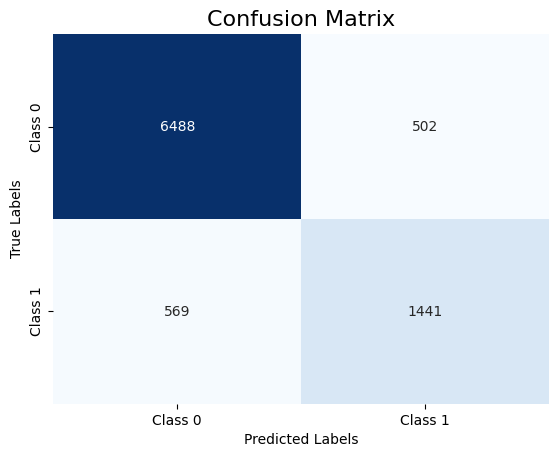

In [14]:
scaler, scaled_X_train = fit_train_data(X_train)
scaled_X_test = scale_X_test(X_test)

def confusion_plot():
    model = LogisticRegression()
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    matrix = None
    ### Start of Code ###
    matrix = confusion_matrix(y_test, y_pred) # fill in with the relevant values
    ### End of Code ###
    ax = sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
                     xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")
    ax.set_title("Confusion Matrix", fontsize=16)

confusion_plot()